In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("C:\\Users\\ADMIN\\Downloads\\matplotlib_sales_clean_1000.csv")

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Create Month column
df["Month"] = df["Order_Date"].dt.to_period("M").astype(str)
df.head()

,Order_ID,Order_Date,City,Product_Category,Customer_Segment,Customer_Age,Units_Sold,Unit_Price,Discount_Pct,Customer_Rating,Gross_Sales,Discount_Amount,Revenue,Cost,Profit,Month
0,ORD00849,2025-01-01,Pune,Home & Kitchen,Budget,36,5,13359.07,2.33,3.4,66795.35,1556.33,65239.02,45347.81,19891.21,2025-01
1,ORD00678,2025-01-01,Hyderabad,Home & Kitchen,Premium,42,2,13594.04,19.92,3.9,27188.08,5415.87,21772.21,15198.49,6573.72,2025-01
2,ORD00649,2025-01-01,Delhi,Home & Kitchen,Budget,25,5,1657.67,2.85,2.7,8288.35,236.22,8052.13,4569.99,3482.14,2025-01
3,ORD00756,2025-01-01,Bengaluru,Home & Kitchen,Premium,31,3,2487.88,32.94,3.7,7463.64,2458.52,5005.12,3547.03,1458.09,2025-01
4,ORD00992,2025-01-01,Delhi,Beauty,Regular,43,4,20911.12,26.06,4.2,83644.48,21797.75,61846.73,36979.40,24867.33,2025-01


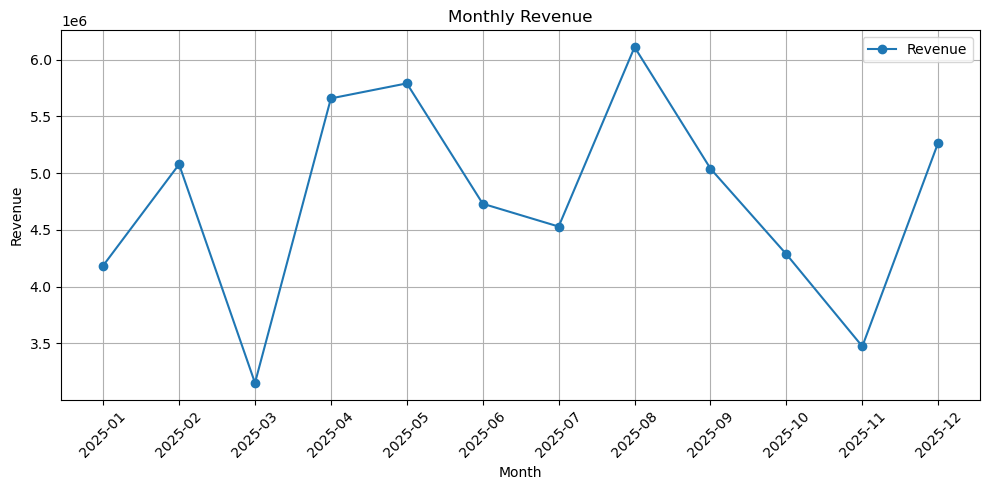

In [19]:
# 1. Plot monthly Revenue as a line chart. Add title, axis labels, markers, grid, and legend.
monthly_revenue = df.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(10, 5))
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o",
    label="Revenue"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

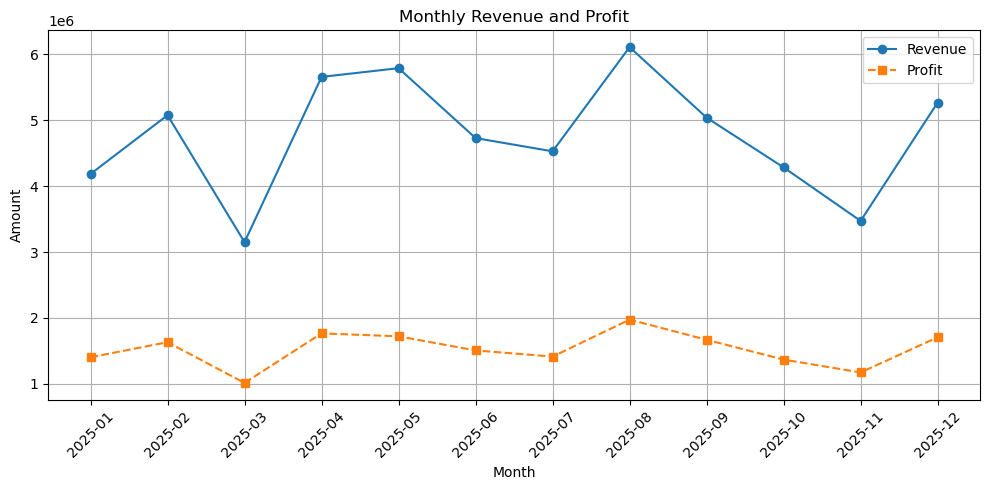

In [20]:
# 2. Plot monthly Revenue and profit on the same chart using different line style.
monthly = df.groupby("Month")[["Revenue", "Profit"]].sum()

plt.figure(figsize=(10, 5))

plt.plot(
    monthly.index,
    monthly["Revenue"],
    marker="o",
    linestyle="-",
    label="Revenue"
)

plt.plot(
    monthly.index,
    monthly["Profit"],
    marker="s",
    linestyle="--",
    label="Profit"
)

plt.title("Monthly Revenue and Profit")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

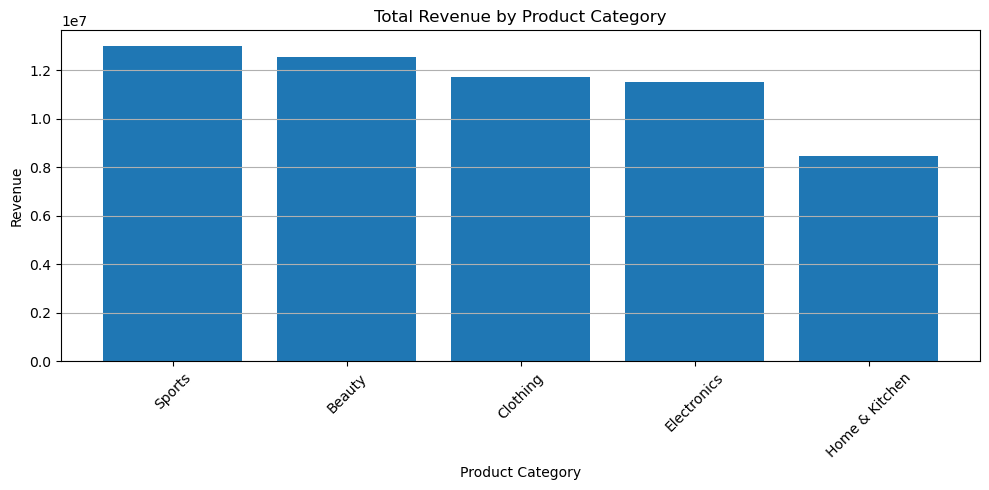

In [21]:
# 3. Create a bar chart of total Revenue by product_Category and sort the categories from highest to lowest renenue.
category_revenue = df.groupby("Product_Category")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(category_revenue.index, category_revenue.values)

plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

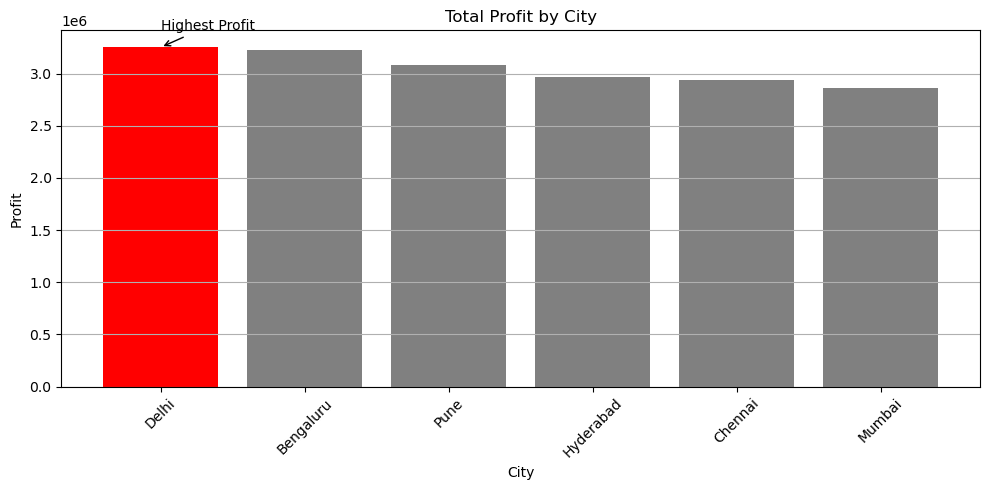

In [22]:
# 4. Create a bar chart of total Profit by City and higlight the city with the highest profit.
city_profit = df.groupby("City")["Profit"].sum().sort_values(ascending=False)

colors = ["gray"] * len(city_profit)
colors[0] = "red"

plt.figure(figsize=(10, 5))
plt.bar(city_profit.index, city_profit.values, color=colors)

plt.title("Total Profit by City")
plt.xlabel("City")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.annotate(
    "Highest Profit",
    xy=(0, city_profit.iloc[0]),
    xytext=(0, city_profit.iloc[0] * 1.05),
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()
plt.show()

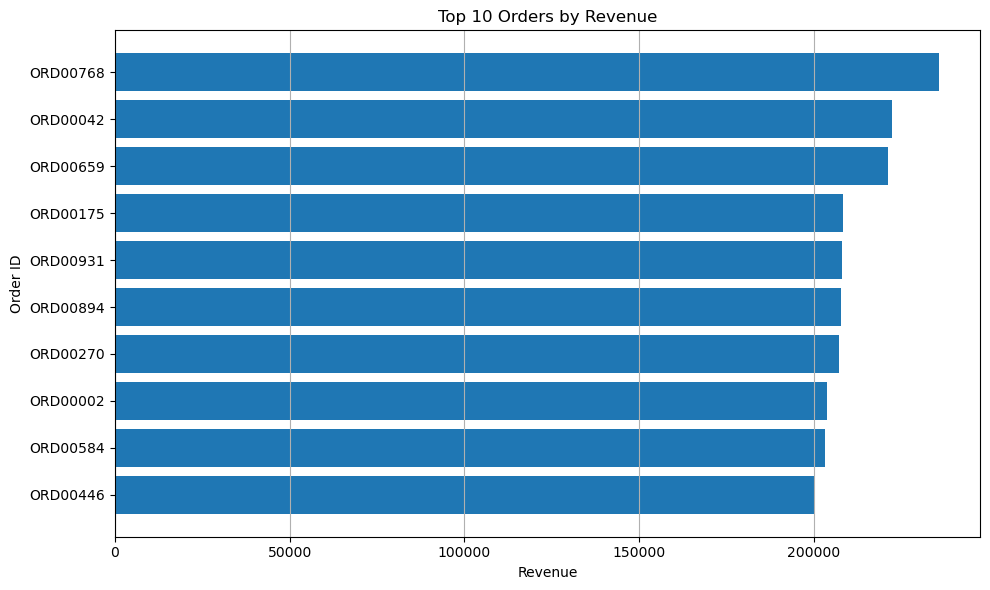

In [23]:
# 5. Create a horizontal bar chart showing the top 10 orders based on Revenue.
top10_revenue = df.nlargest(10, "Revenue").sort_values("Revenue")

plt.figure(figsize=(10, 6))
plt.barh(top10_revenue["Order_ID"], top10_revenue["Revenue"])

plt.title("Top 10 Orders by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Order ID")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

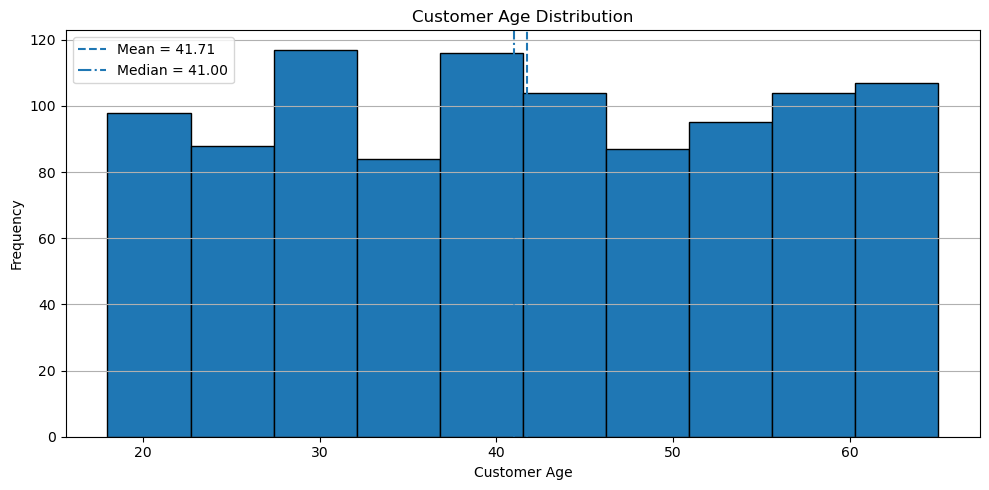

In [24]:
# 6. Create a histogram of Customer_Age using 10 appropriate bins. Add mean and median lines.
mean_age = df["Customer_Age"].mean()
median_age = df["Customer_Age"].median()

plt.figure(figsize=(10, 5))

plt.hist(
    df["Customer_Age"],
    bins=10,
    edgecolor="black"
)

plt.axvline(mean_age, linestyle="--", label=f"Mean = {mean_age:.2f}")
plt.axvline(median_age, linestyle="-.", label=f"Median = {median_age:.2f}")

plt.title("Customer Age Distribution")
plt.xlabel("Customer Age")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()

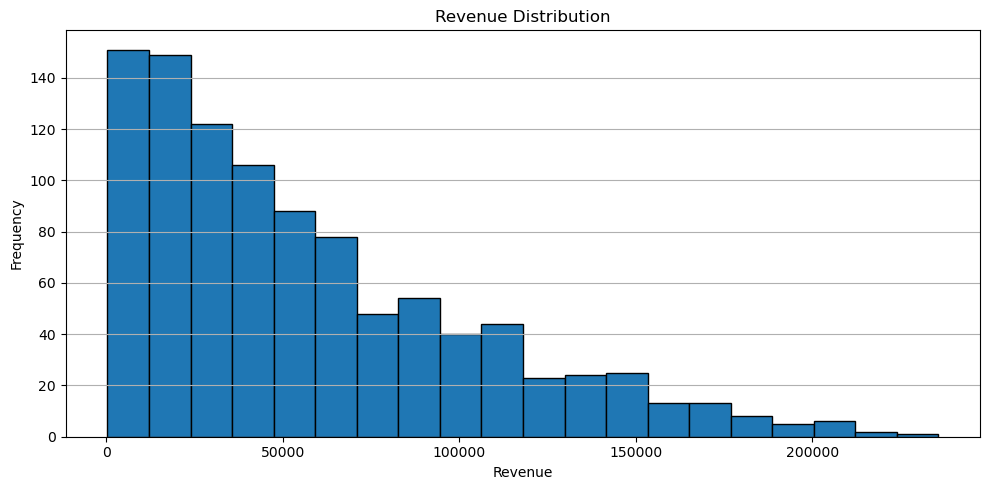

Revenue Skewness: 1.0684343515534862


In [25]:
# 7. Create a histogram of Revenue and explain visually whether the distribution appears symmetric or skewed.
plt.figure(figsize=(10, 5))

plt.hist(
    df["Revenue"],
    bins=20,
    edgecolor="black"
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

print("Revenue Skewness:", df["Revenue"].skew())

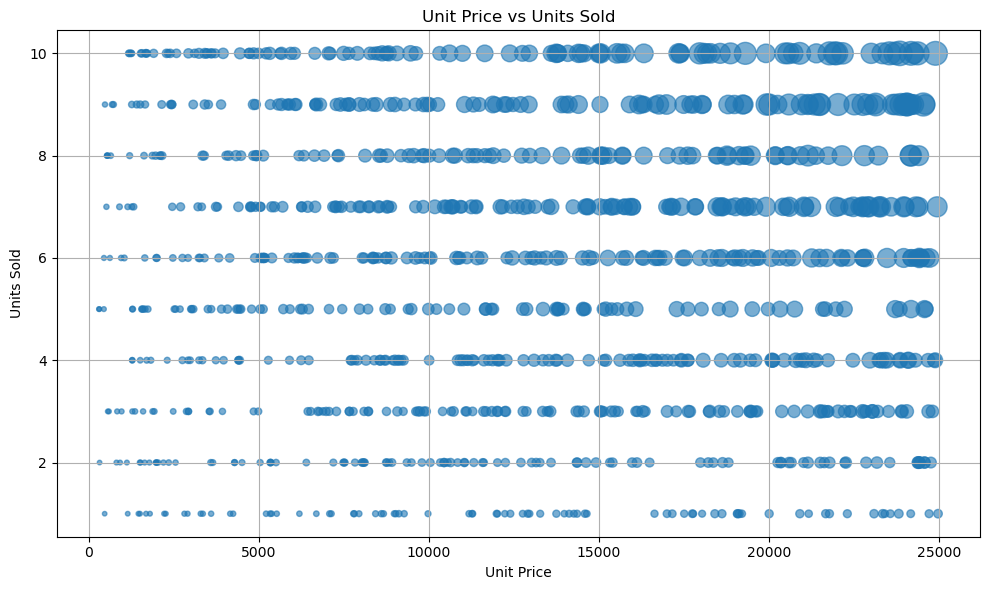

In [26]:
# 8. Create a scatter plot of Unit_Price vs Units_Sold. Use different marker sizes based on Revenue.
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Unit_Price"],
    df["Units_Sold"],
    s=df["Revenue"] / df["Revenue"].max() * 300 + 10,
    alpha=0.6
)

plt.title("Unit Price vs Units Sold")
plt.xlabel("Unit Price")
plt.ylabel("Units Sold")
plt.grid(True)
plt.tight_layout()
plt.show()

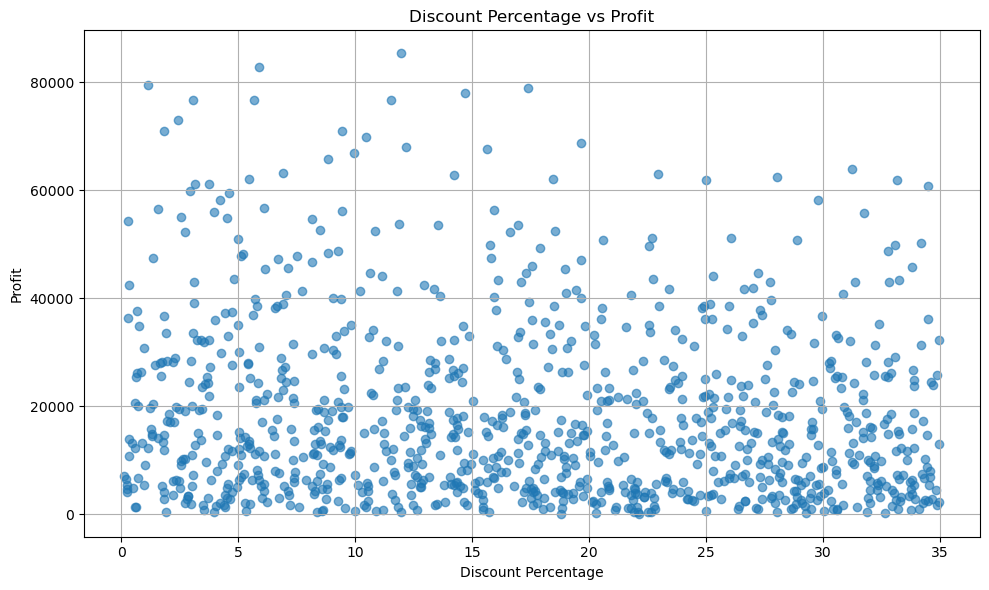

Correlation: -0.13122547808850551


In [27]:
# 9. Create a scatter plot of Discount_Pct vs Profit and determine visually whether higher discounts are associated with lower profit.
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Discount_Pct"],
    df["Profit"],
    alpha=0.6
)

plt.title("Discount Percentage vs Profit")
plt.xlabel("Discount Percentage")
plt.ylabel("Profit")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Correlation:", df["Discount_Pct"].corr(df["Profit"]))

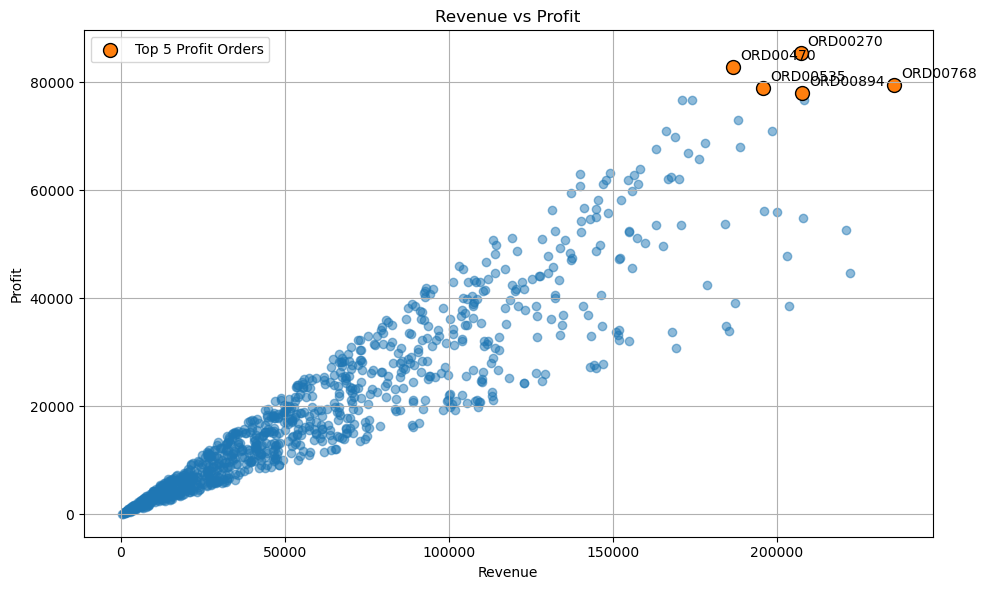

In [28]:
# 10. Create a scatter plot of Revenue vs Profit and highlight the five orders having the highest profit.
top5_profit = df.nlargest(5, "Profit")

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Revenue"],
    df["Profit"],
    alpha=0.5
)

plt.scatter(
    top5_profit["Revenue"],
    top5_profit["Profit"],
    s=100,
    edgecolor="black",
    label="Top 5 Profit Orders"
)

for _, row in top5_profit.iterrows():
    plt.annotate(
        row["Order_ID"],
        (row["Revenue"], row["Profit"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

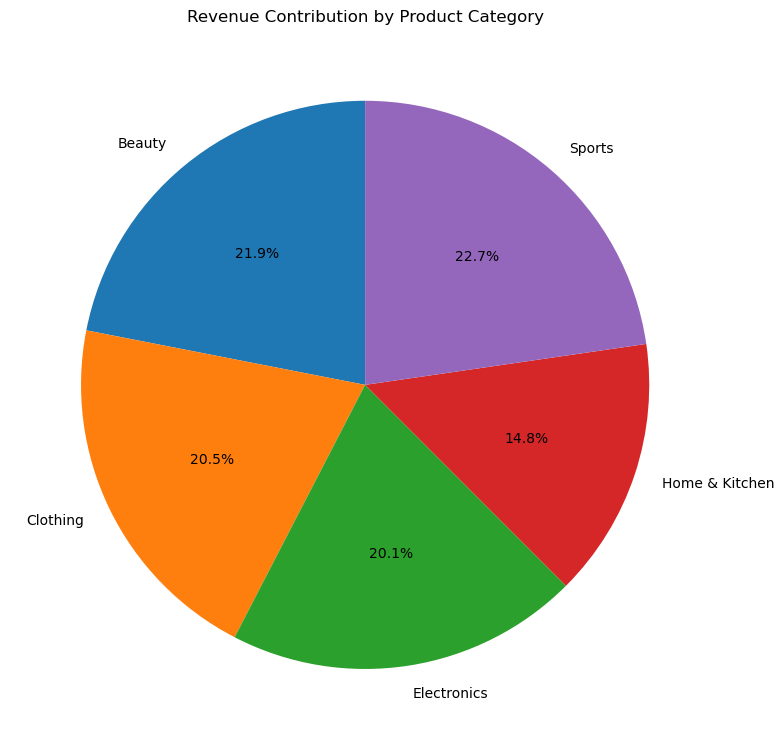

In [30]:
# 11. Create a pie chart of Revenue contribution by Product_Category. Display percentage values.
category_revenue = df.groupby("Product_Category")["Revenue"].sum()

plt.figure(figsize=(8, 8))

plt.pie(
    category_revenue.values,
    labels=category_revenue.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Contribution by Product Category")
plt.tight_layout()
plt.show()

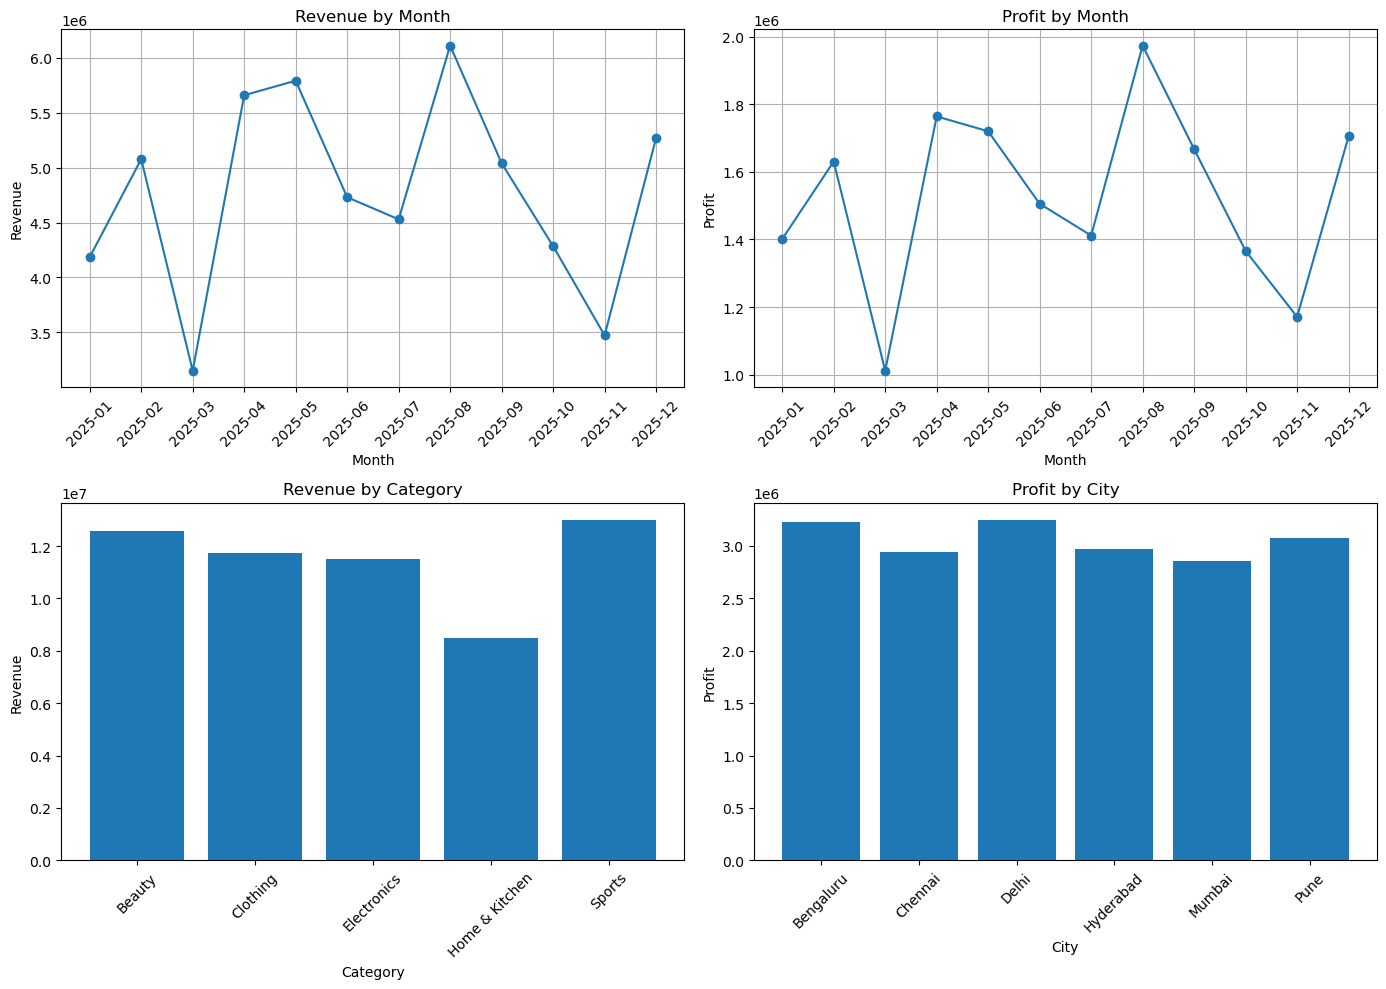

In [31]:
# 12. Create a 2×2 subplot containing:
monthly = df.groupby("Month")[["Revenue", "Profit"]].sum()
category_revenue = df.groupby("Product_Category")["Revenue"].sum()
city_profit = df.groupby("City")["Profit"].sum()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Revenue by month
axes[0, 0].plot(monthly.index, monthly["Revenue"], marker="o")
axes[0, 0].set_title("Revenue by Month")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].grid(True)
axes[0, 0].tick_params(axis="x", rotation=45)

# Profit by month
axes[0, 1].plot(monthly.index, monthly["Profit"], marker="o")
axes[0, 1].set_title("Profit by Month")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Profit")
axes[0, 1].grid(True)
axes[0, 1].tick_params(axis="x", rotation=45)

# Revenue by category
axes[1, 0].bar(category_revenue.index, category_revenue.values)
axes[1, 0].set_title("Revenue by Category")
axes[1, 0].set_xlabel("Category")
axes[1, 0].set_ylabel("Revenue")
axes[1, 0].tick_params(axis="x", rotation=45)

# Profit by city
axes[1, 1].bar(city_profit.index, city_profit.values)
axes[1, 1].set_title("Profit by City")
axes[1, 1].set_xlabel("City")
axes[1, 1].set_ylabel("Profit")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

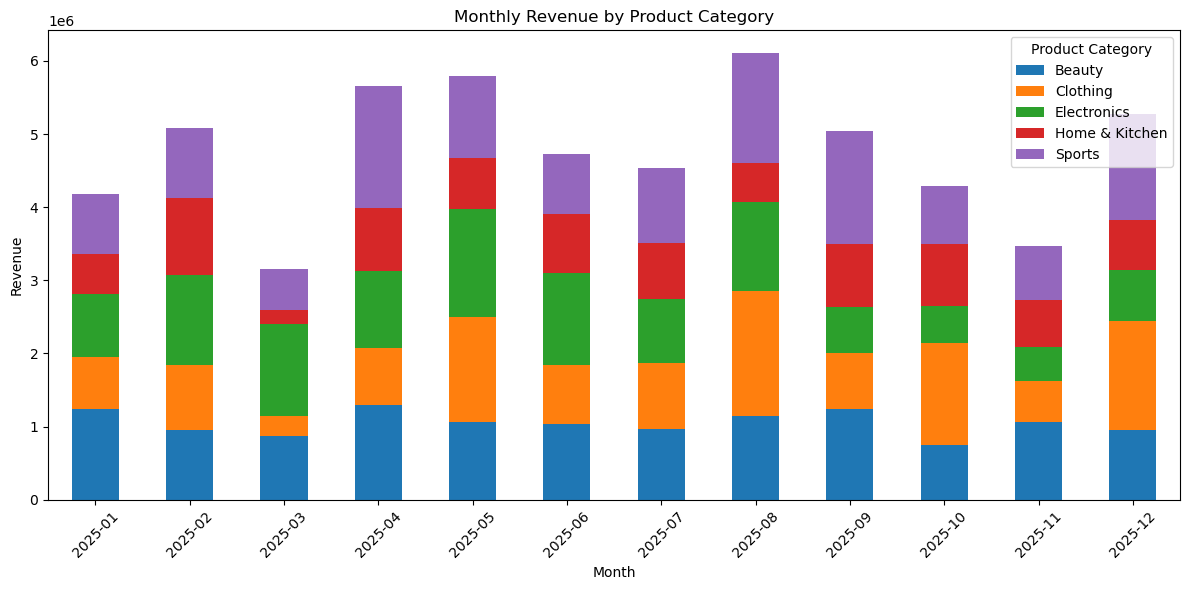

In [32]:
# 13. Create a stacked bar chart showing Revenue by month for each Product_Category.
pivot = df.pivot_table(
    index="Month",
    columns="Product_Category",
    values="Revenue",
    aggfunc="sum"
)

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Monthly Revenue by Product Category")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend(title="Product Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

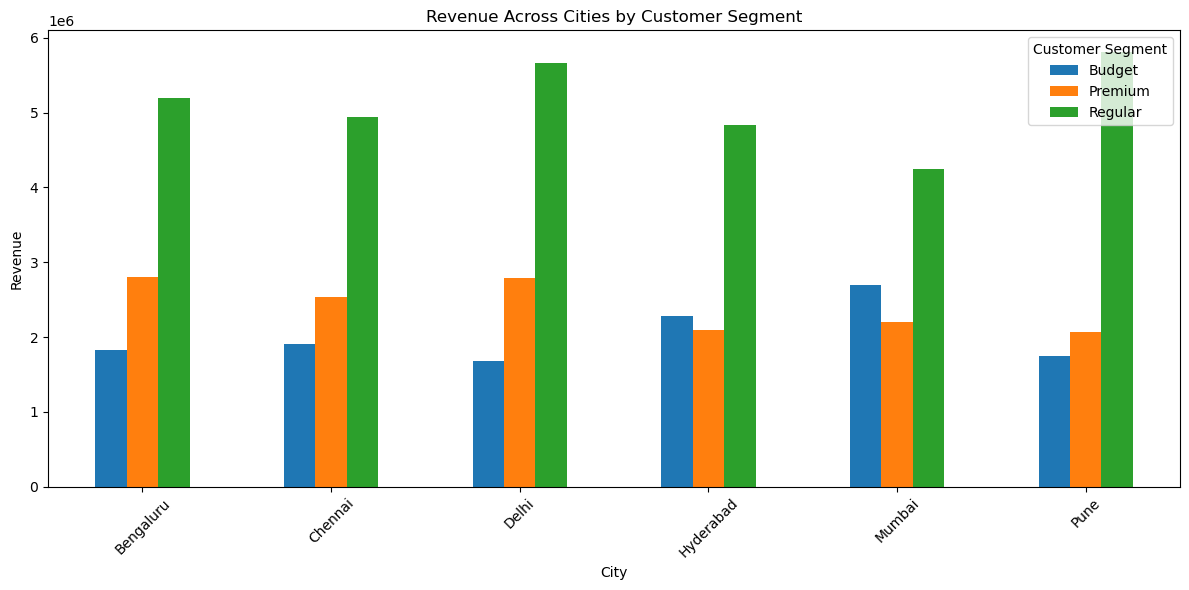

In [33]:
# 14. Create a grouped bar chart comparing Revenue across cities for different customer segments.
pivot = df.pivot_table(
    index="City",
    columns="Customer_Segment",
    values="Revenue",
    aggfunc="sum"
)

pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Revenue Across Cities by Customer Segment")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.legend(title="Customer Segment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

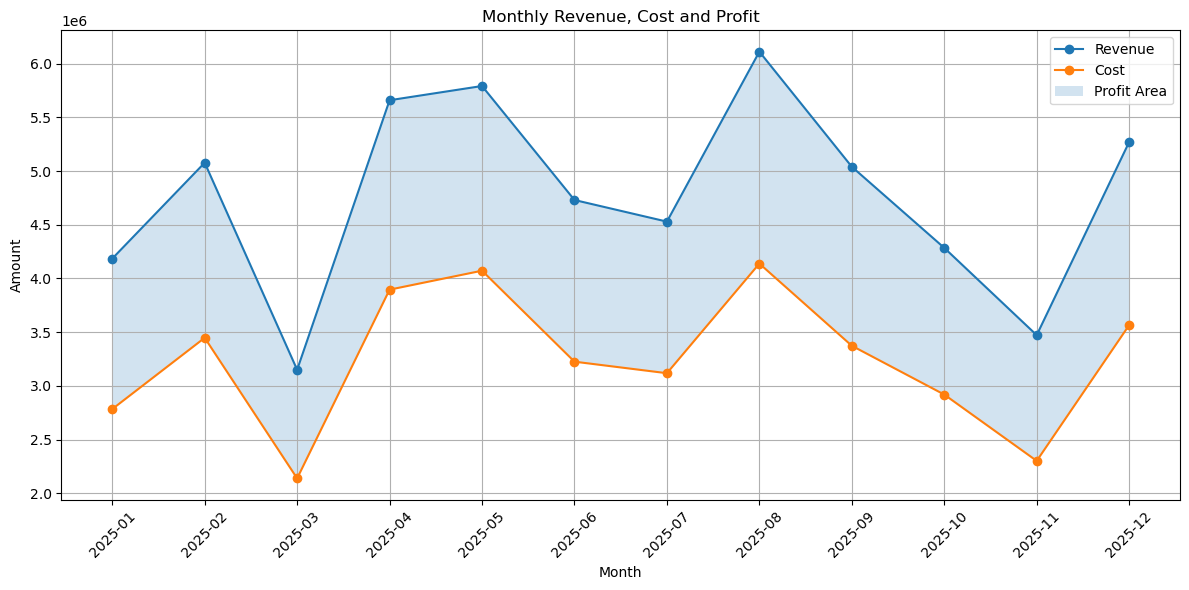

In [34]:
# 15. Plot monthly Revenue and Cost together and shade the area between the two lines to represent Profit.
monthly = df.groupby("Month")[["Revenue", "Cost"]].sum()

plt.figure(figsize=(12, 6))

plt.plot(
    monthly.index,
    monthly["Revenue"],
    marker="o",
    label="Revenue"
)

plt.plot(
    monthly.index,
    monthly["Cost"],
    marker="o",
    label="Cost"
)

plt.fill_between(
    monthly.index,
    monthly["Revenue"],
    monthly["Cost"],
    alpha=0.2,
    label="Profit Area"
)

plt.title("Monthly Revenue, Cost and Profit")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

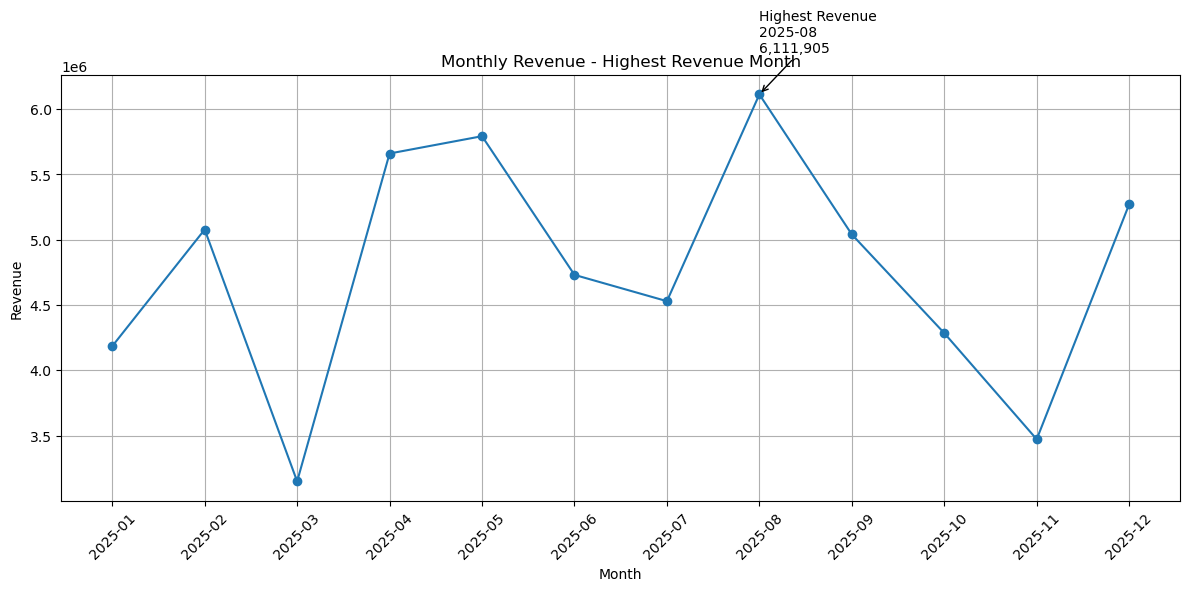

In [35]:
# 16. Find the month with the highest Revenue and annotate that point on the line chart.
monthly_revenue = df.groupby("Month")["Revenue"].sum()

highest_month = monthly_revenue.idxmax()
highest_value = monthly_revenue.max()

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

plt.annotate(
    f"Highest Revenue\n{highest_month}\n{highest_value:,.0f}",
    xy=(highest_month, highest_value),
    xytext=(0, 30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly Revenue - Highest Revenue Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

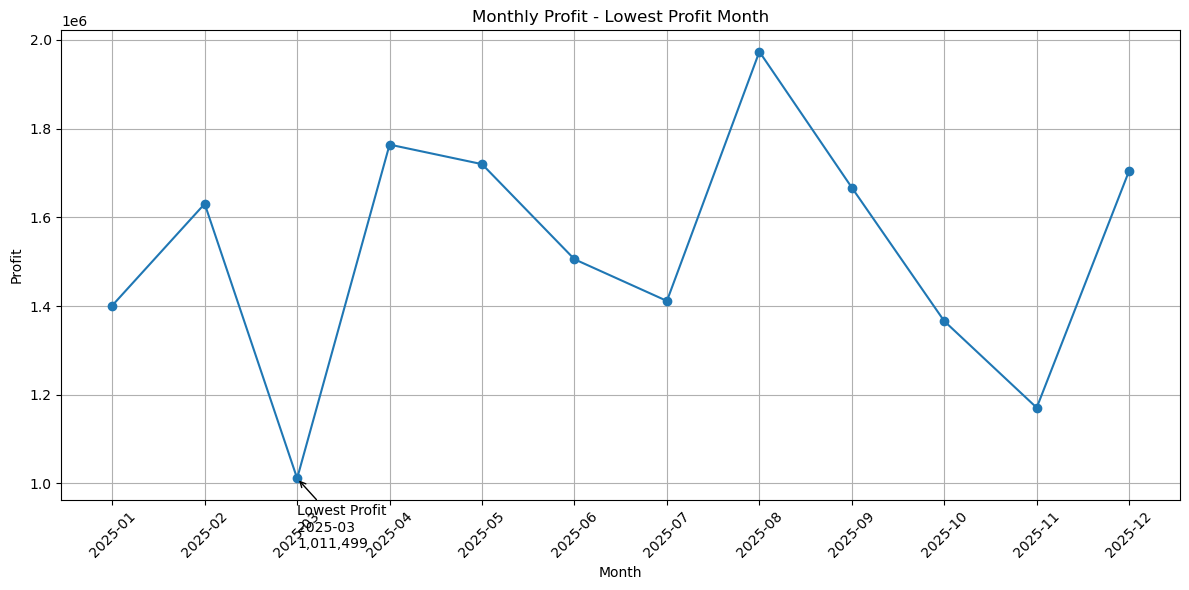

In [36]:
# 17. Find the month with the lowest Profit and annotate it on the visualization.
monthly_profit = df.groupby("Month")["Profit"].sum()

lowest_month = monthly_profit.idxmin()
lowest_value = monthly_profit.min()

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_profit.index,
    monthly_profit.values,
    marker="o"
)

plt.annotate(
    f"Lowest Profit\n{lowest_month}\n{lowest_value:,.0f}",
    xy=(lowest_month, lowest_value),
    xytext=(0, -50),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly Profit - Lowest Profit Month")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

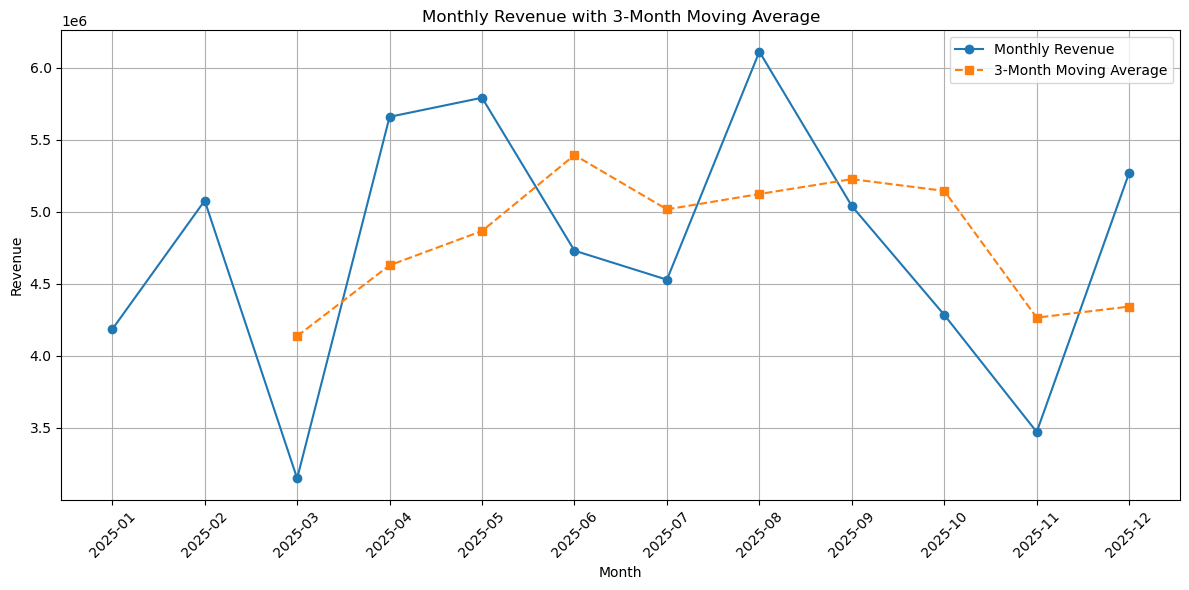

In [37]:
# 18. Create a line chart of monthly Revenue and calculate a 3-month moving average. Plot both lines together.
monthly_revenue = df.groupby("Month")["Revenue"].sum()

moving_average = monthly_revenue.rolling(window=3).mean()

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o",
    label="Monthly Revenue"
)

plt.plot(
    moving_average.index,
    moving_average.values,
    marker="s",
    linestyle="--",
    label="3-Month Moving Average"
)

plt.title("Monthly Revenue with 3-Month Moving Average")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

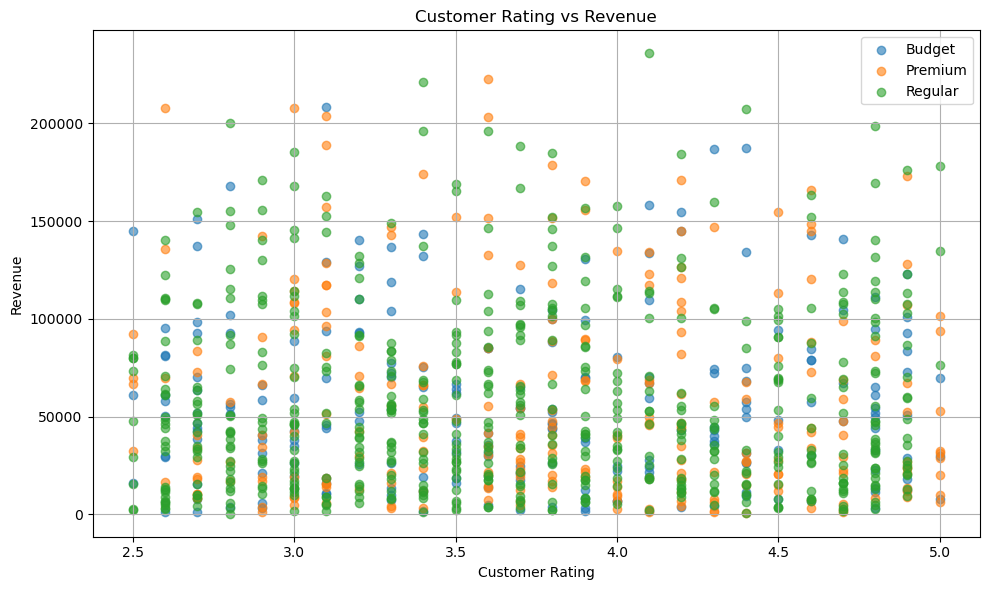

In [38]:
# 19. Create a scatter plot between Customer_Rating and Revenue. Use Customer_Segment to visually distinguish the points.
plt.figure(figsize=(10, 6))

segments = df["Customer_Segment"].unique()

for segment in segments:
    data = df[df["Customer_Segment"] == segment]

    plt.scatter(
        data["Customer_Rating"],
        data["Revenue"],
        label=segment,
        alpha=0.6
    )

plt.title("Customer Rating vs Revenue")
plt.xlabel("Customer Rating")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

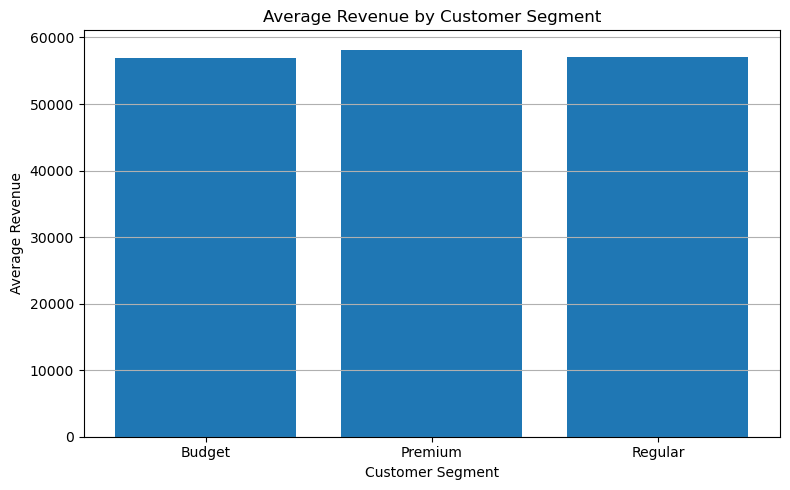

In [39]:
# 20.Create a visualization comparing the average Revenue of Premium, Regular, and Budget customers.
avg_revenue = df.groupby("Customer_Segment")["Revenue"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    avg_revenue.index,
    avg_revenue.values
)

plt.title("Average Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Revenue")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23652\2197722618.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


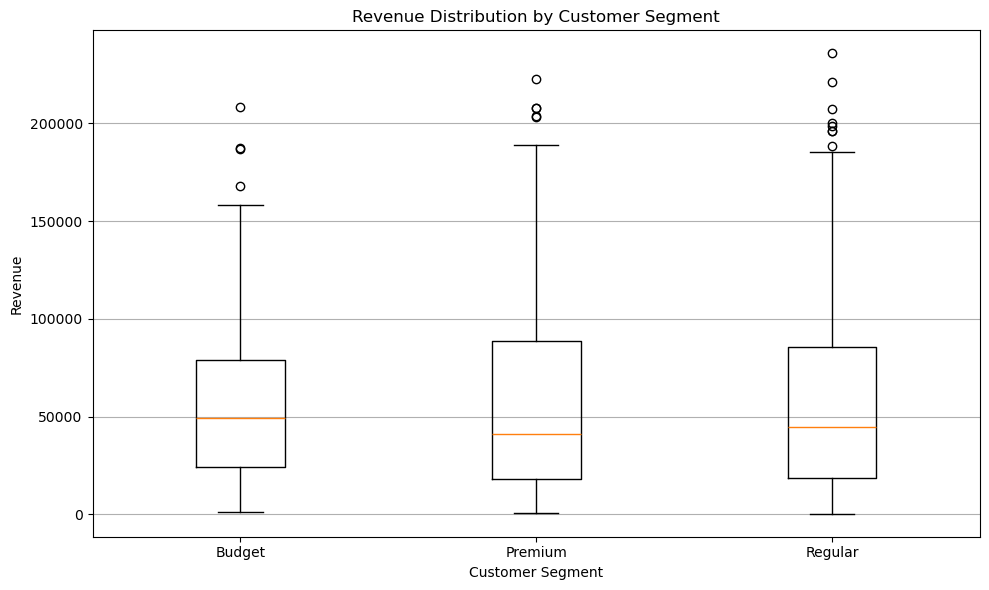

In [40]:
# 21. Create a boxplot of Revenue for each Customer_Segment. Compare the distributions visually.
segments = df["Customer_Segment"].unique()

data = [
    df[df["Customer_Segment"] == segment]["Revenue"]
    for segment in segments
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    data,
    labels=segments
)

plt.title("Revenue Distribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23652\3823747475.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


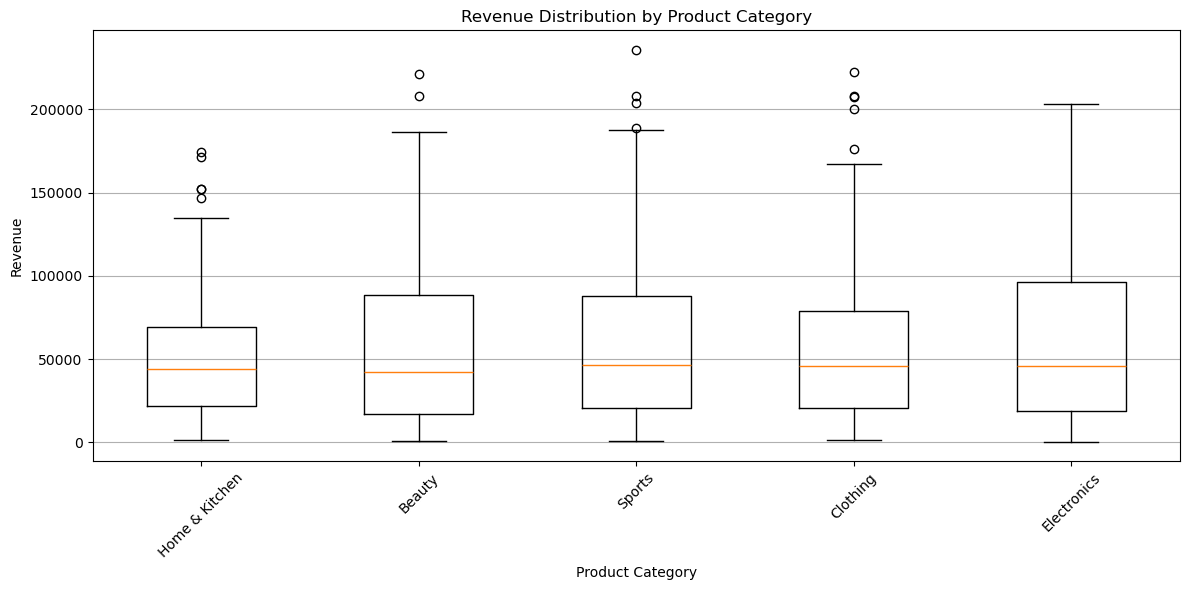

Category with largest spread:
Sports
Spread: 234934.78


In [41]:
# 22. categories = df["Product_Category"].unique()
categories = df["Product_Category"].unique()

data = [
    df[df["Product_Category"] == category]["Revenue"]
    for category in categories
]

plt.figure(figsize=(12, 6))

plt.boxplot(
    data,
    labels=categories
)

plt.title("Revenue Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

spread = df.groupby("Product_Category")["Revenue"].agg(
    lambda x: x.max() - x.min()
)

print("Category with largest spread:")
print(spread.idxmax())
print("Spread:", spread.max())

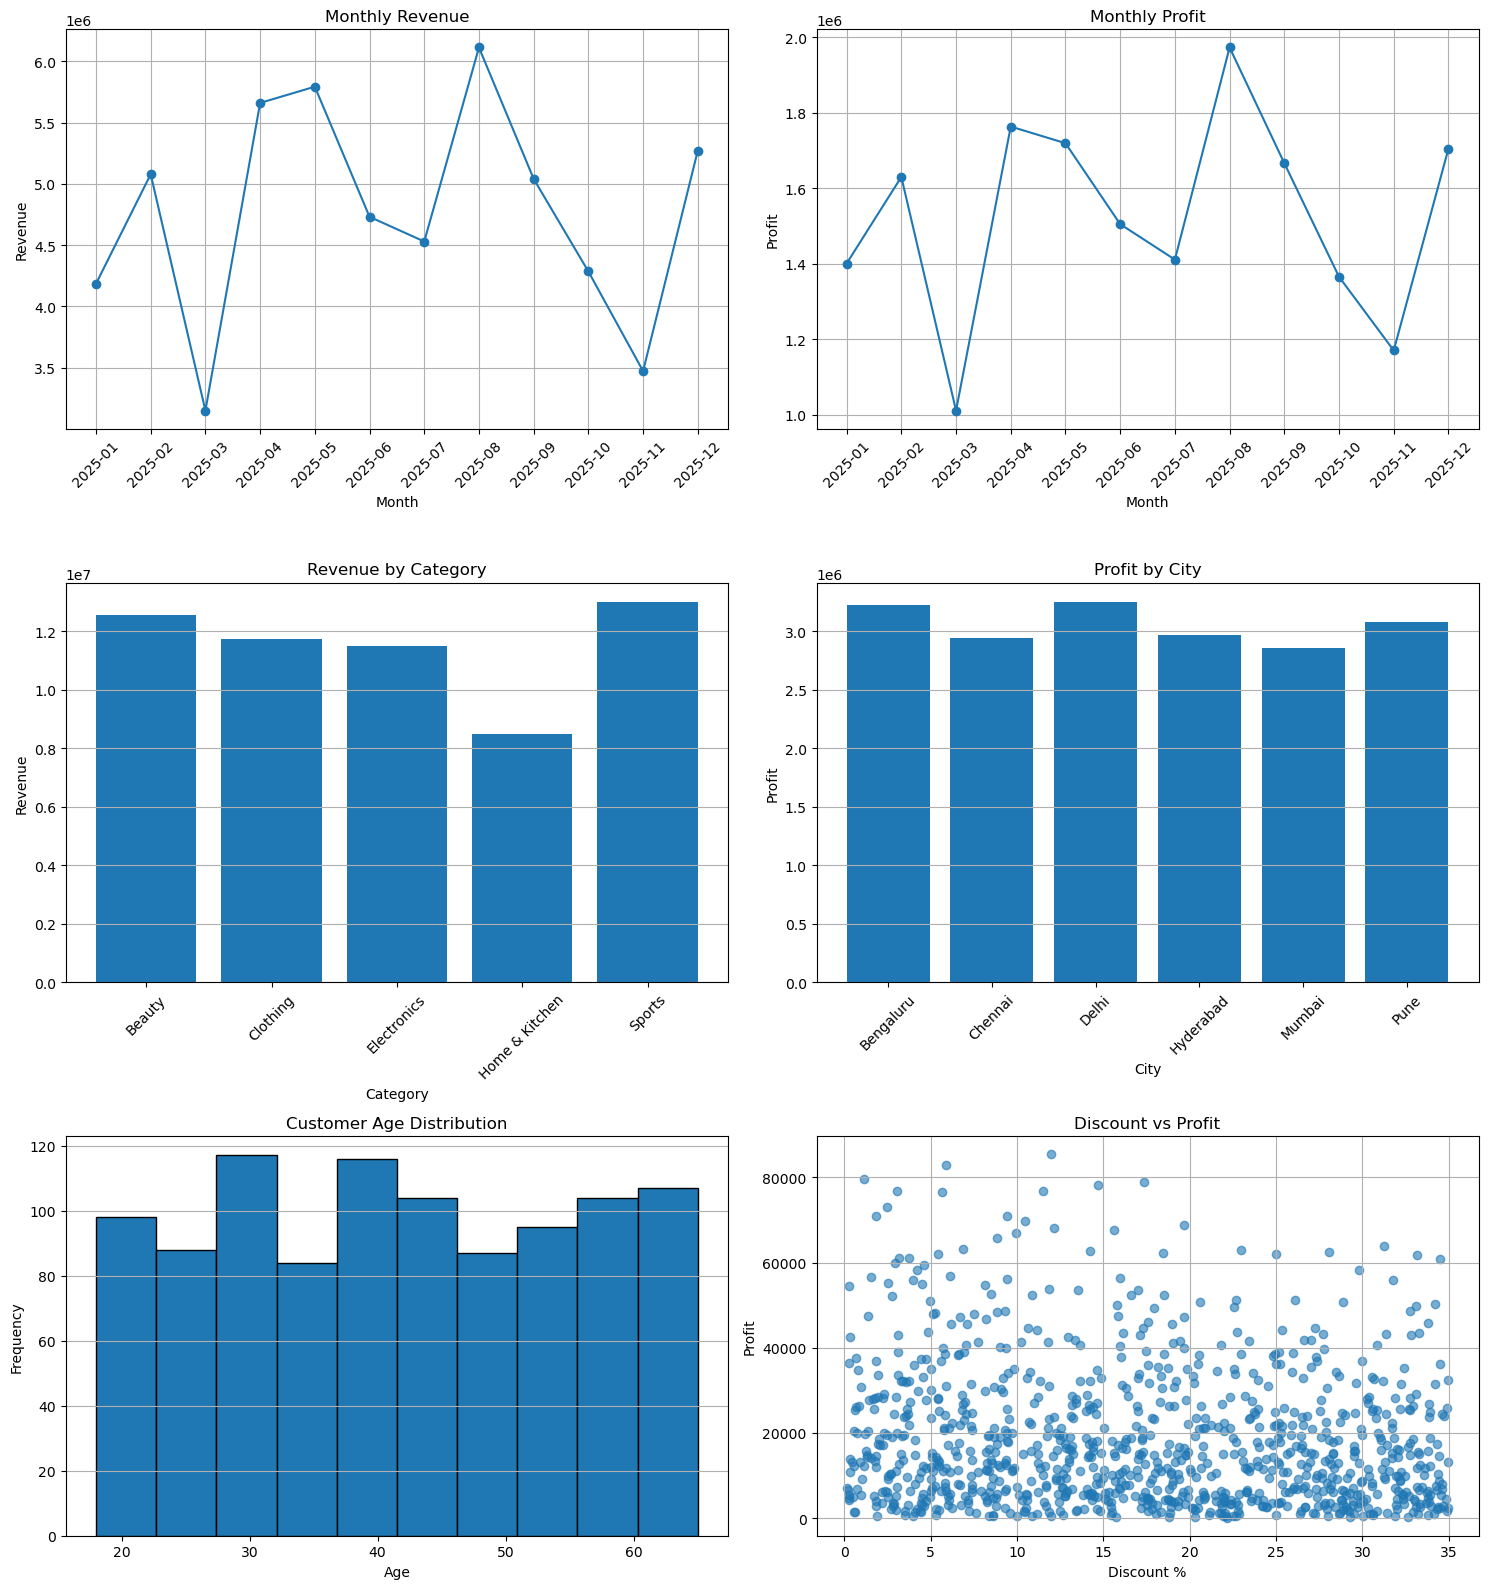

In [42]:
# 23. Create a 3×2 Matplotlib dashboard containing:
monthly = df.groupby("Month")[["Revenue", "Profit"]].sum()
category_revenue = df.groupby("Product_Category")["Revenue"].sum()
city_profit = df.groupby("City")["Profit"].sum()

fig, axes = plt.subplots(3, 2, figsize=(15, 16))

# 1 Monthly Revenue
axes[0, 0].plot(monthly.index, monthly["Revenue"], marker="o")
axes[0, 0].set_title("Monthly Revenue")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].grid(True)
axes[0, 0].tick_params(axis="x", rotation=45)

# 2 Monthly Profit
axes[0, 1].plot(monthly.index, monthly["Profit"], marker="o")
axes[0, 1].set_title("Monthly Profit")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Profit")
axes[0, 1].grid(True)
axes[0, 1].tick_params(axis="x", rotation=45)

# 3 Category Revenue
axes[1, 0].bar(category_revenue.index, category_revenue.values)
axes[1, 0].set_title("Revenue by Category")
axes[1, 0].set_xlabel("Category")
axes[1, 0].set_ylabel("Revenue")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].grid(axis="y")

# 4 City Profit
axes[1, 1].bar(city_profit.index, city_profit.values)
axes[1, 1].set_title("Profit by City")
axes[1, 1].set_xlabel("City")
axes[1, 1].set_ylabel("Profit")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(axis="y")

# 5 Customer Age
axes[2, 0].hist(df["Customer_Age"], bins=10, edgecolor="black")
axes[2, 0].set_title("Customer Age Distribution")
axes[2, 0].set_xlabel("Age")
axes[2, 0].set_ylabel("Frequency")
axes[2, 0].grid(axis="y")

# 6 Discount vs Profit
axes[2, 1].scatter(
    df["Discount_Pct"],
    df["Profit"],
    alpha=0.6
)
axes[2, 1].set_title("Discount vs Profit")
axes[2, 1].set_xlabel("Discount %")
axes[2, 1].set_ylabel("Profit")
axes[2, 1].grid(True)

plt.tight_layout()
plt.show()

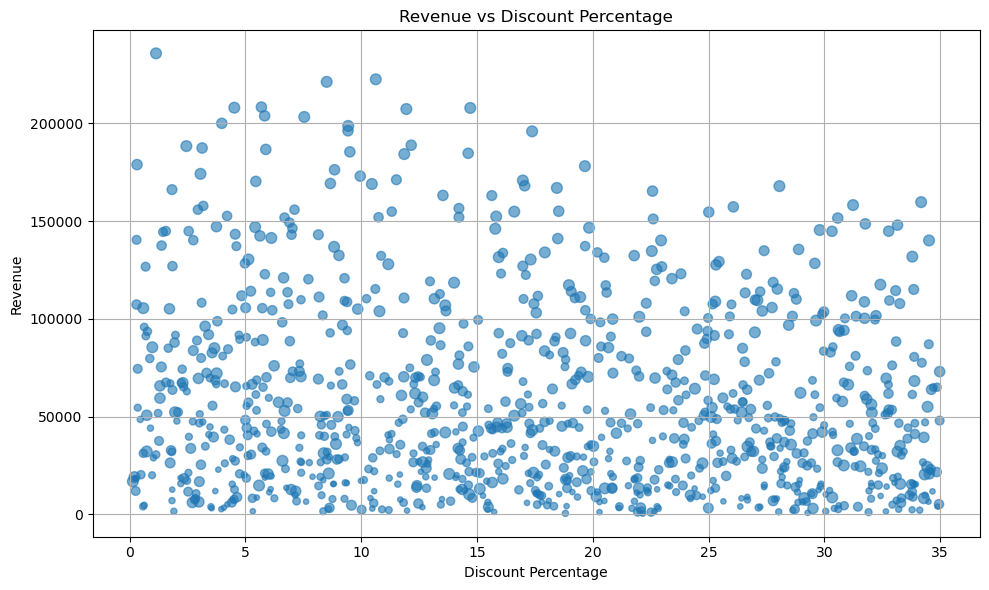

In [43]:
# 24. Create a chart showing Revenue vs Discount_Pct and use marker size to represent Units_Sold.
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Discount_Pct"],
    df["Revenue"],
    s=df["Units_Sold"] * 5 + 10,
    alpha=0.6
)

plt.title("Revenue vs Discount Percentage")
plt.xlabel("Discount Percentage")
plt.ylabel("Revenue")
plt.grid(True)
plt.tight_layout()
plt.show()

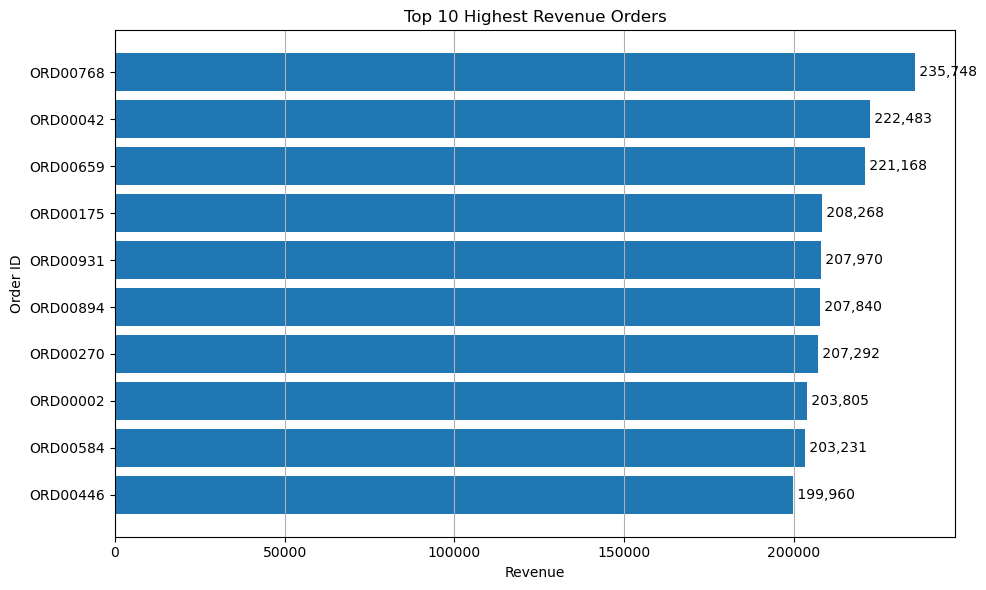

In [44]:
# 25. Identify the top 10 highest-revenue orders and visualize them using a horizontal bar chart. Display the Order_ID beside each bar.
top10 = df.nlargest(10, "Revenue").sort_values("Revenue")

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top10["Order_ID"],
    top10["Revenue"]
)

plt.title("Top 10 Highest Revenue Orders")
plt.xlabel("Revenue")
plt.ylabel("Order ID")
plt.grid(axis="x")

for bar, value in zip(bars, top10["Revenue"]):
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

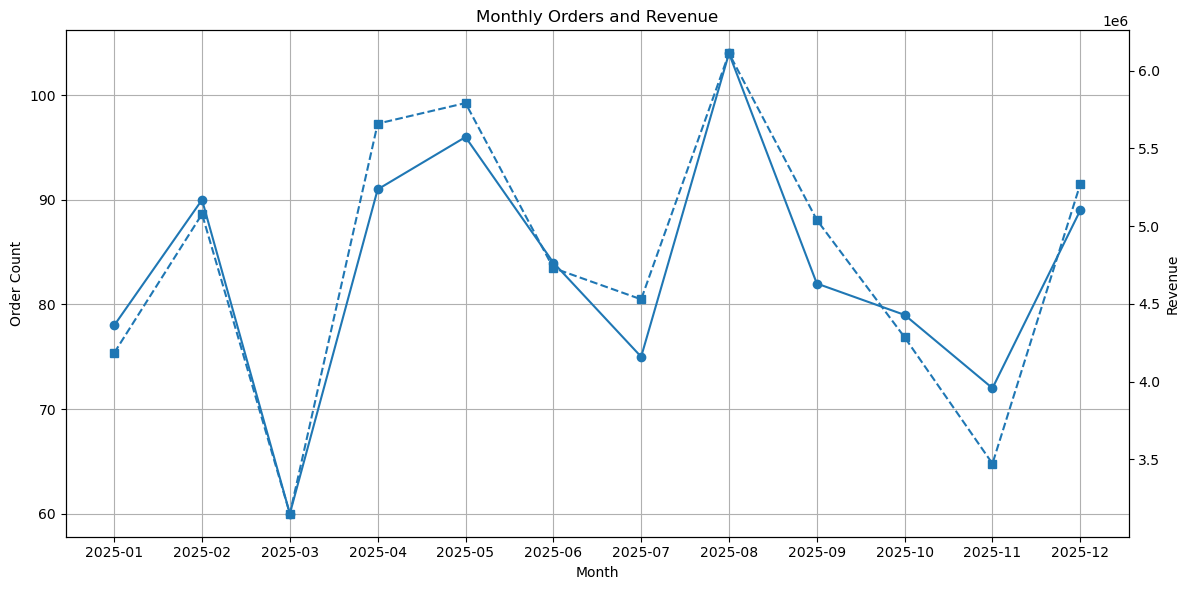

In [45]:
# 26. Create a visualization showing monthly Orders and Revenue using two Y-axes. Use the first Y-axis for order count and the second for revenue.
monthly_orders = df.groupby("Month")["Order_ID"].count()
monthly_revenue = df.groupby("Month")["Revenue"].sum()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker="o",
    label="Order Count"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Order Count")
ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="s",
    linestyle="--",
    label="Revenue"
)

ax2.set_ylabel("Revenue")

plt.title("Monthly Orders and Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

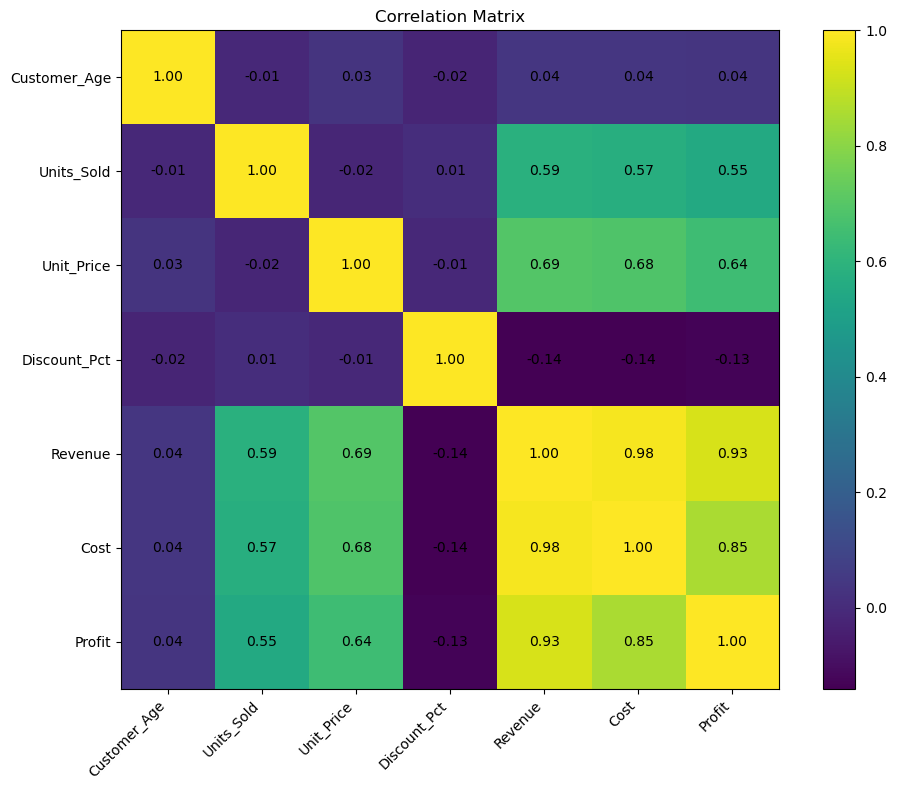

In [46]:
# 27. Create a heatmap-style visualization using Matplotlib only for the correlation matrix of: Customer_Age, Units_Sold, Unit_Price, Discount_Pct, Revenue, Cost, and Profit.
columns = [
    "Customer_Age",
    "Units_Sold",
    "Unit_Price",
    "Discount_Pct",
    "Revenue",
    "Cost",
    "Profit"
]

corr = df[columns].corr()

fig, ax = plt.subplots(figsize=(10, 8))

image = ax.imshow(corr)

ax.set_xticks(np.arange(len(columns)))
ax.set_yticks(np.arange(len(columns)))

ax.set_xticklabels(columns, rotation=45, ha="right")
ax.set_yticklabels(columns)

plt.colorbar(image)

for i in range(len(columns)):
    for j in range(len(columns)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

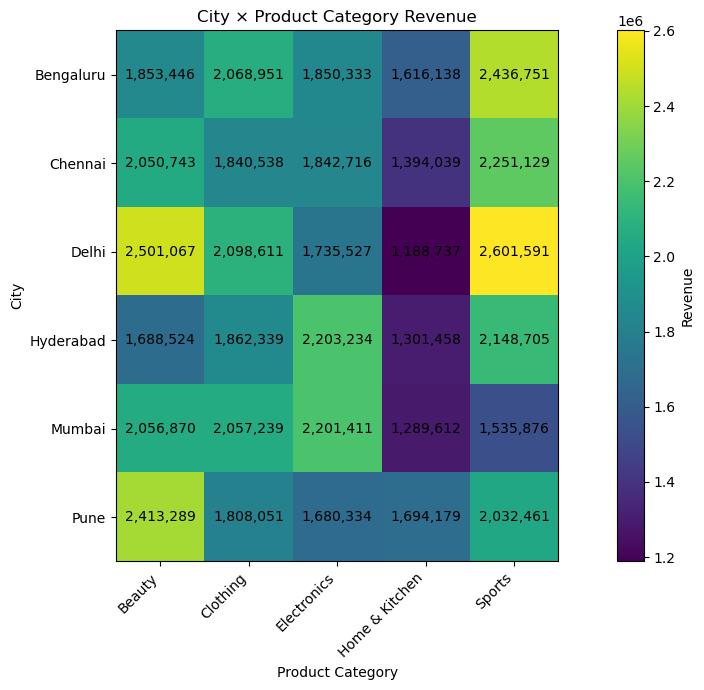

In [47]:
# 28. Create a dashboard comparing City × Product_Category Revenue. Use a suitable visualization to show which combinations generate the highest revenue.
pivot = df.pivot_table(
    index="City",
    columns="Product_Category",
    values="Revenue",
    aggfunc="sum"
)

plt.figure(figsize=(12, 7))

image = plt.imshow(pivot.values)

plt.xticks(
    np.arange(len(pivot.columns)),
    pivot.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(len(pivot.index)),
    pivot.index
)

plt.colorbar(image, label="Revenue")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        plt.text(
            j,
            i,
            f"{pivot.iloc[i, j]:,.0f}",
            ha="center",
            va="center"
        )

plt.title("City × Product Category Revenue")
plt.xlabel("Product Category")
plt.ylabel("City")
plt.tight_layout()
plt.show()

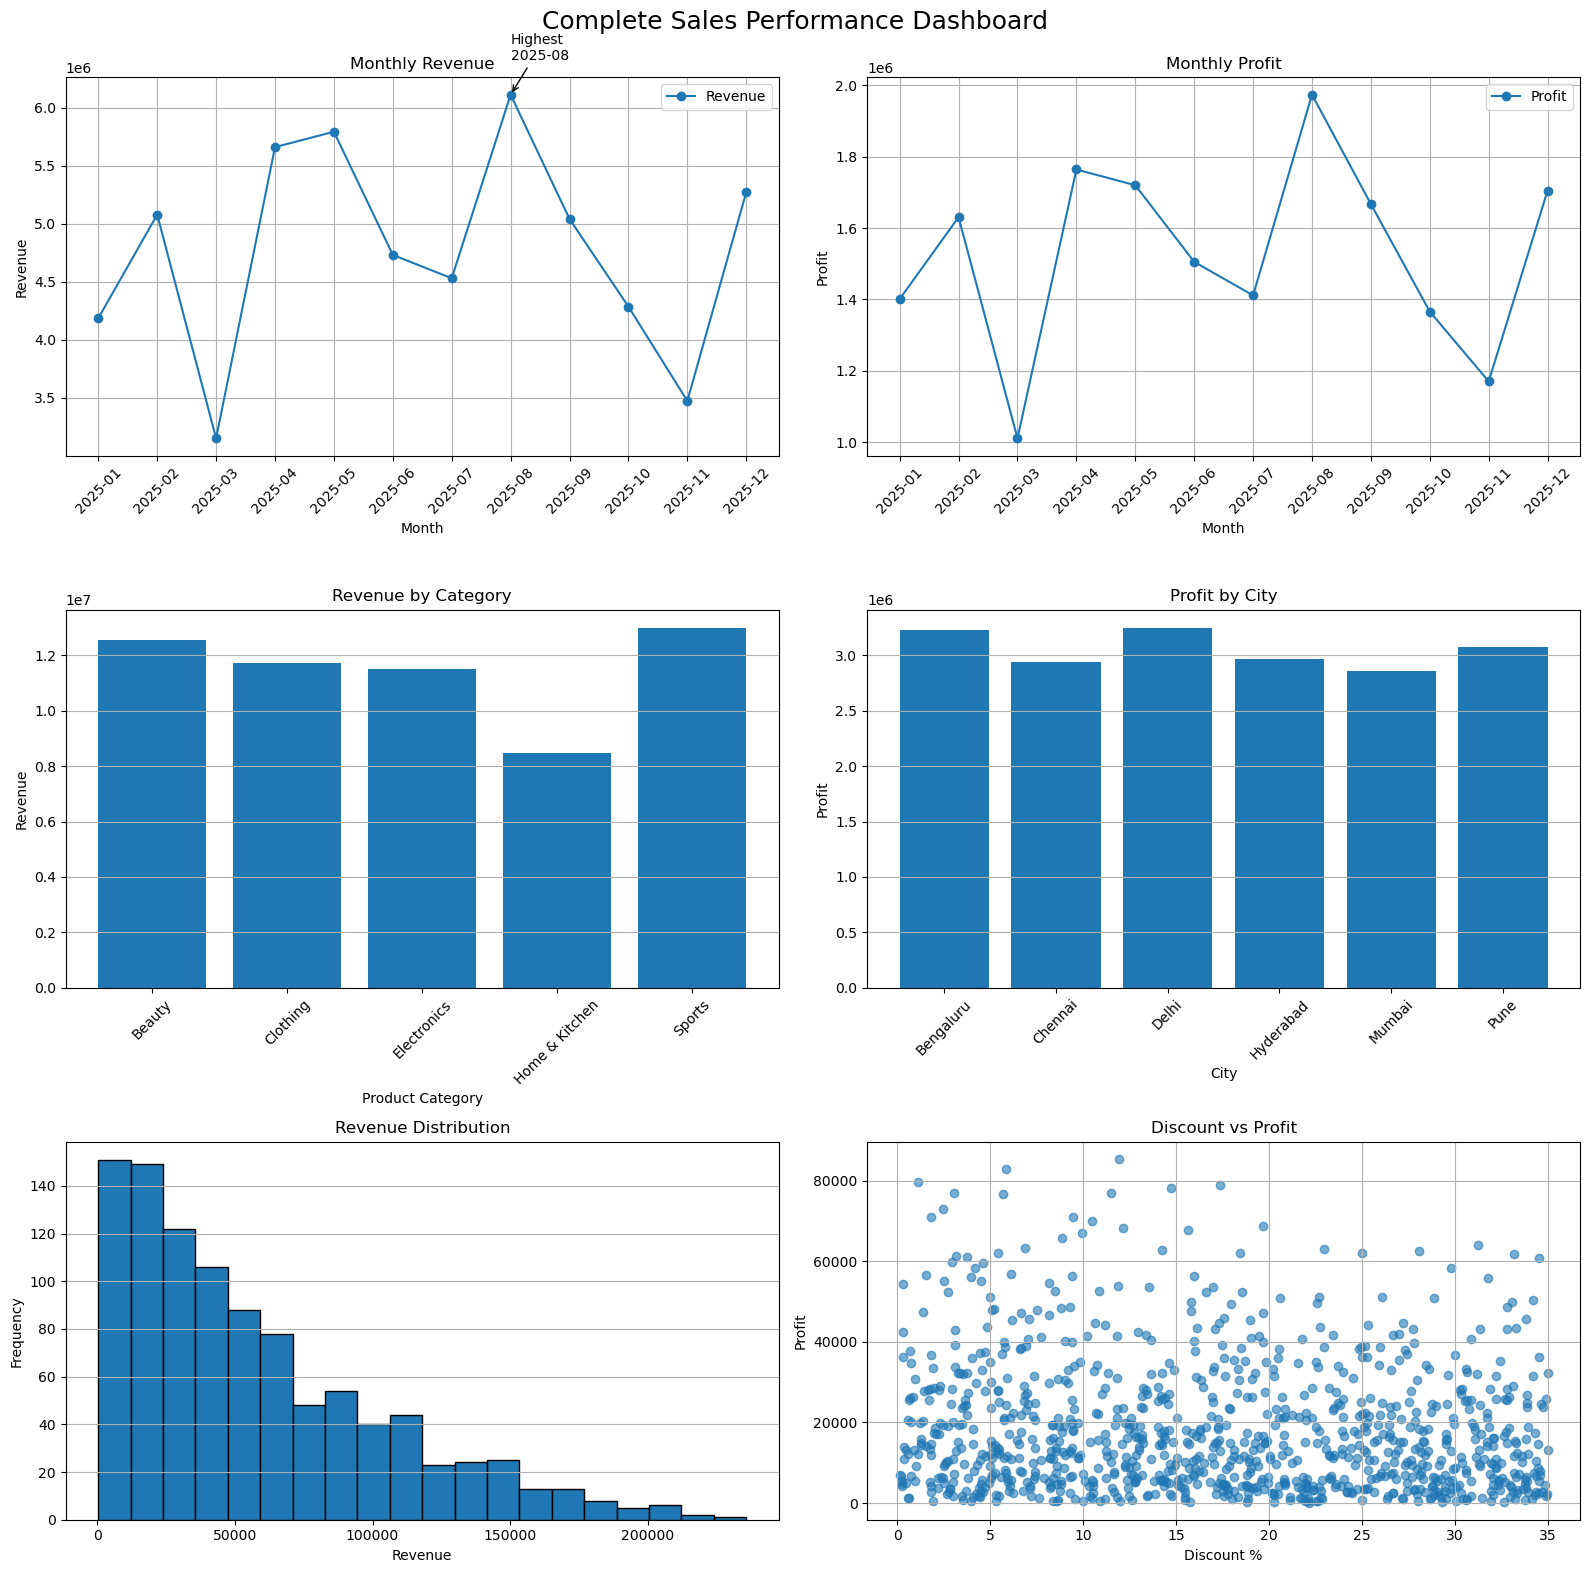

In [48]:
# 29. Create a complete sales performance dashboard with: 
monthly = df.groupby("Month")[["Revenue", "Profit"]].sum()
category_revenue = df.groupby("Product_Category")["Revenue"].sum()
city_profit = df.groupby("City")["Profit"].sum()

fig, axes = plt.subplots(3, 2, figsize=(16, 16))

# Monthly Revenue
axes[0, 0].plot(
    monthly.index,
    monthly["Revenue"],
    marker="o",
    label="Revenue"
)

highest_month = monthly["Revenue"].idxmax()
highest_value = monthly["Revenue"].max()

axes[0, 0].annotate(
    f"Highest\n{highest_month}",
    xy=(highest_month, highest_value),
    xytext=(0, 25),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

axes[0, 0].set_title("Monthly Revenue")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].grid(True)
axes[0, 0].legend()
axes[0, 0].tick_params(axis="x", rotation=45)

# Monthly Profit
axes[0, 1].plot(
    monthly.index,
    monthly["Profit"],
    marker="o",
    label="Profit"
)

axes[0, 1].set_title("Monthly Profit")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Profit")
axes[0, 1].grid(True)
axes[0, 1].legend()
axes[0, 1].tick_params(axis="x", rotation=45)

# Category Revenue
axes[1, 0].bar(
    category_revenue.index,
    category_revenue.values
)

axes[1, 0].set_title("Revenue by Category")
axes[1, 0].set_xlabel("Product Category")
axes[1, 0].set_ylabel("Revenue")
axes[1, 0].grid(axis="y")
axes[1, 0].tick_params(axis="x", rotation=45)

# City Profit
axes[1, 1].bar(
    city_profit.index,
    city_profit.values
)

axes[1, 1].set_title("Profit by City")
axes[1, 1].set_xlabel("City")
axes[1, 1].set_ylabel("Profit")
axes[1, 1].grid(axis="y")
axes[1, 1].tick_params(axis="x", rotation=45)

# Revenue Distribution
axes[2, 0].hist(
    df["Revenue"],
    bins=20,
    edgecolor="black"
)

axes[2, 0].set_title("Revenue Distribution")
axes[2, 0].set_xlabel("Revenue")
axes[2, 0].set_ylabel("Frequency")
axes[2, 0].grid(axis="y")

# Discount vs Profit
axes[2, 1].scatter(
    df["Discount_Pct"],
    df["Profit"],
    alpha=0.6
)

axes[2, 1].set_title("Discount vs Profit")
axes[2, 1].set_xlabel("Discount %")
axes[2, 1].set_ylabel("Profit")
axes[2, 1].grid(True)

plt.suptitle(
    "Complete Sales Performance Dashboard",
    fontsize=18
)

plt.tight_layout()
plt.show()

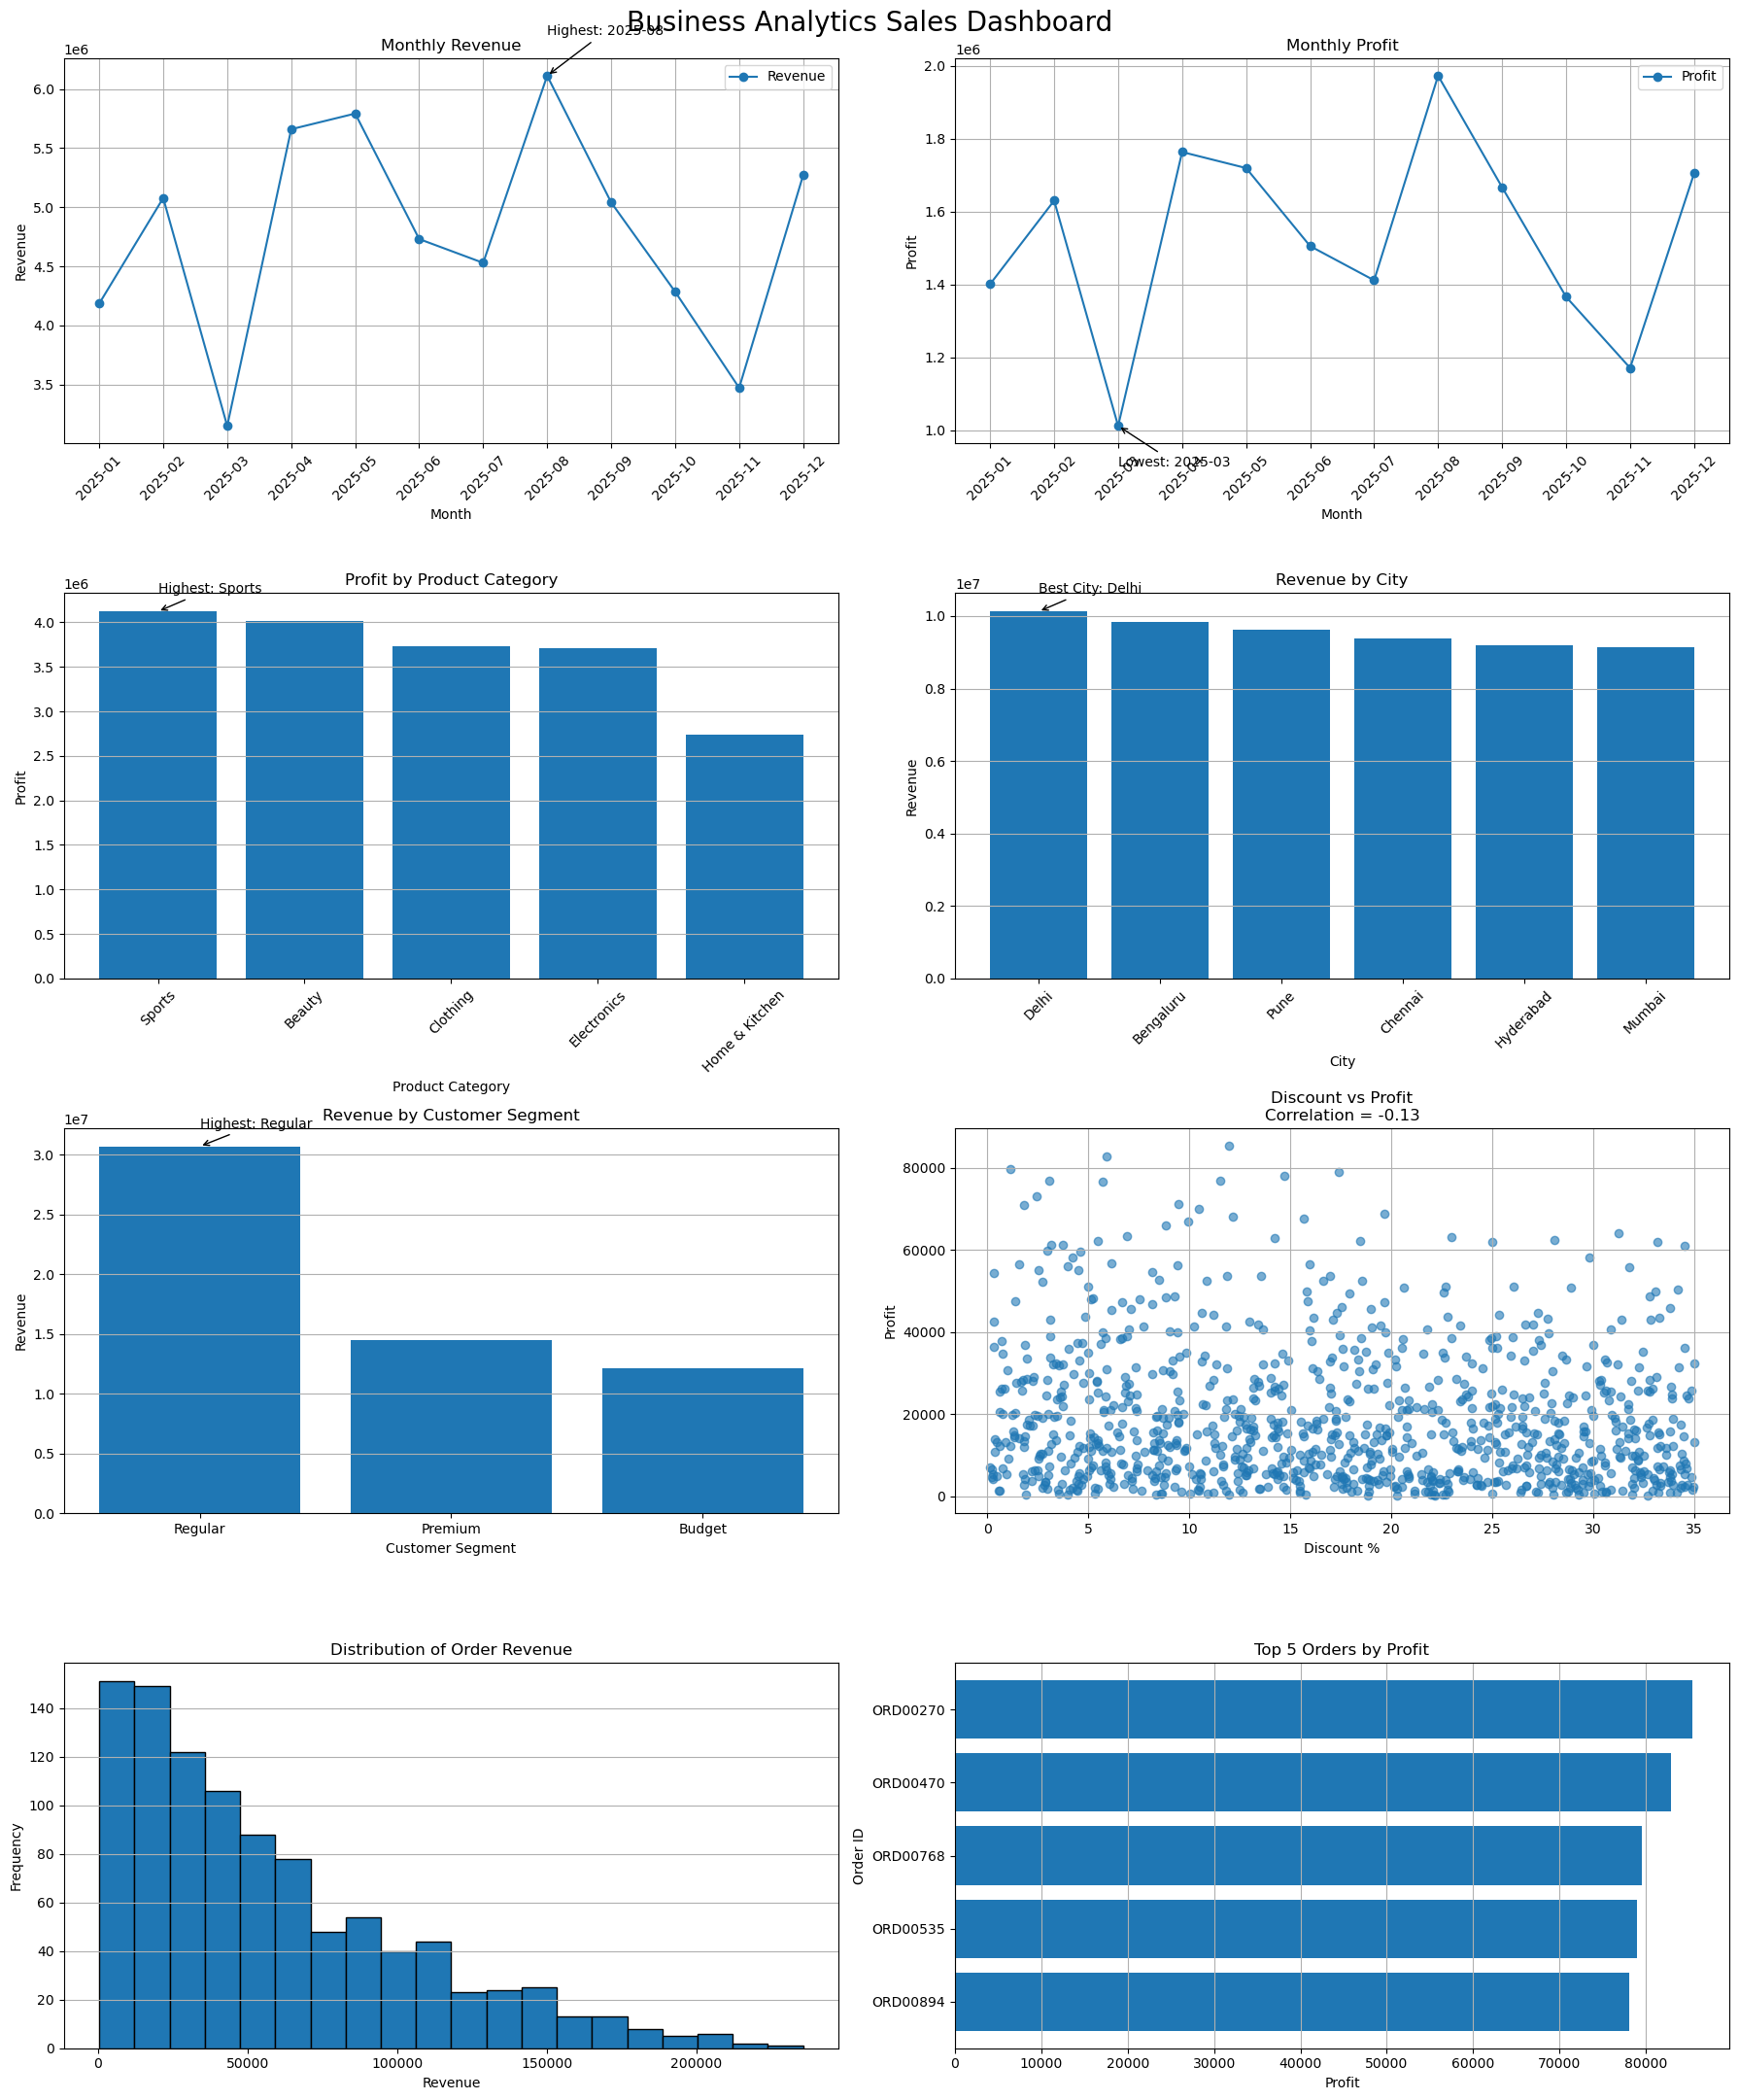

========== BUSINESS FINDINGS ==========
1. Highest Revenue Month: 2025-08 Revenue = 6111904.58
2. Highest Profit Category: Sports Profit = 4122156.78
3. Best Performing City: Delhi Revenue = 10125533.13
4. Highest Revenue Customer Segment: Regular Revenue = 30687622.79
5. Discount vs Profit Correlation: -0.131
   Higher discounts appear to be associated with lower profit.
6. Revenue Skewness: 1.068
7. Top 5 Profit Orders:
     Order_ID    Revenue    Profit
29   ORD00270  207291.80  85397.07
188  ORD00470  186628.58  82864.07
691  ORD00768  235748.38  79593.70
303  ORD00535  195874.26  78940.69
857  ORD00894  207840.22  78128.92


In [50]:
# 30. Final Challenge — Business Analytics Visualization
# FINAL BUSINESS ANALYTICS DASHBOARD
monthly = df.groupby("Month")[["Revenue", "Profit"]].sum()
category_profit = (df.groupby("Product_Category")["Profit"].sum().sort_values(ascending=False))
city_revenue = (df.groupby("City")["Revenue"].sum().sort_values(ascending=False))
segment_revenue = (df.groupby("Customer_Segment")["Revenue"].sum().sort_values(ascending=False))
top5_profit = df.nlargest(5, "Profit")

# Important findings
highest_revenue_month = monthly["Revenue"].idxmax()
highest_revenue_value = monthly["Revenue"].max()

highest_profit_category = category_profit.idxmax()
highest_profit_category_value = category_profit.max()

best_city = city_revenue.idxmax()
best_city_value = city_revenue.max()

best_segment = segment_revenue.idxmax()
best_segment_value = segment_revenue.max()

discount_profit_corr = df["Discount_Pct"].corr(df["Profit"])

# Create dashboard
fig, axes = plt.subplots(4, 2, figsize=(18, 22))

# 1. Monthly Revenue
axes[0, 0].plot(
    monthly.index,
    monthly["Revenue"],
    marker="o",
    label="Revenue"
)

axes[0, 0].set_title("Monthly Revenue")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].grid(True)
axes[0, 0].legend()
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 0].annotate(
    f"Highest: {highest_revenue_month}",
    xy=(
        highest_revenue_month,
        highest_revenue_value
    ),
    xytext=(0, 30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# 2. Monthly Profit
axes[0, 1].plot(
    monthly.index,
    monthly["Profit"],
    marker="o",
    label="Profit"
)

lowest_profit_month = monthly["Profit"].idxmin()
lowest_profit_value = monthly["Profit"].min()

axes[0, 1].set_title("Monthly Profit")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Profit")
axes[0, 1].grid(True)
axes[0, 1].legend()
axes[0, 1].tick_params(axis="x", rotation=45)

axes[0, 1].annotate(
    f"Lowest: {lowest_profit_month}",
    xy=(
        lowest_profit_month,
        lowest_profit_value
    ),
    xytext=(0, -30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# 3. Profit by Product Category
bars = axes[1, 0].bar(
    category_profit.index,
    category_profit.values
)

axes[1, 0].set_title("Profit by Product Category")
axes[1, 0].set_xlabel("Product Category")
axes[1, 0].set_ylabel("Profit")
axes[1, 0].grid(axis="y")
axes[1, 0].tick_params(axis="x", rotation=45)

axes[1, 0].annotate(
    f"Highest: {highest_profit_category}",
    xy=(0, highest_profit_category_value),
    xytext=(0, highest_profit_category_value * 1.05),
    arrowprops=dict(arrowstyle="->")
)

# 4. City Performance
axes[1, 1].bar(
    city_revenue.index,
    city_revenue.values
)

axes[1, 1].set_title("Revenue by City")
axes[1, 1].set_xlabel("City")
axes[1, 1].set_ylabel("Revenue")
axes[1, 1].grid(axis="y")
axes[1, 1].tick_params(axis="x", rotation=45)

axes[1, 1].annotate(
    f"Best City: {best_city}",
    xy=(0, best_city_value),
    xytext=(0, best_city_value * 1.05),
    arrowprops=dict(arrowstyle="->")
)

# 5. Customer Segment Revenue
axes[2, 0].bar(
    segment_revenue.index,
    segment_revenue.values
)

axes[2, 0].set_title("Revenue by Customer Segment")
axes[2, 0].set_xlabel("Customer Segment")
axes[2, 0].set_ylabel("Revenue")
axes[2, 0].grid(axis="y")

axes[2, 0].annotate(
    f"Highest: {best_segment}",
    xy=(0, best_segment_value),
    xytext=(0, best_segment_value * 1.05),
    arrowprops=dict(arrowstyle="->")
)

# 6. Discount vs Profit
axes[2, 1].scatter(
    df["Discount_Pct"],
    df["Profit"],
    alpha=0.6
)

axes[2, 1].set_title(
    f"Discount vs Profit\nCorrelation = {discount_profit_corr:.2f}"
)

axes[2, 1].set_xlabel("Discount %")
axes[2, 1].set_ylabel("Profit")
axes[2, 1].grid(True)

# 7. Revenue Distribution
axes[3, 0].hist(
    df["Revenue"],
    bins=20,
    edgecolor="black"
)

axes[3, 0].set_title("Distribution of Order Revenue")
axes[3, 0].set_xlabel("Revenue")
axes[3, 0].set_ylabel("Frequency")
axes[3, 0].grid(axis="y")

# 8. Top 5 Profit Orders
top5_profit_sorted = top5_profit.sort_values("Profit")

axes[3, 1].barh(
    top5_profit_sorted["Order_ID"],
    top5_profit_sorted["Profit"]
)

axes[3, 1].set_title("Top 5 Orders by Profit")
axes[3, 1].set_xlabel("Profit")
axes[3, 1].set_ylabel("Order ID")
axes[3, 1].grid(axis="x")

# Overall dashboard title
plt.suptitle(
    "Business Analytics Sales Dashboard",
    fontsize=20
)

plt.tight_layout()
plt.show()

# PRINT BUSINESS FINDINGS
print("========== BUSINESS FINDINGS ==========")

print(
    "1. Highest Revenue Month:",
    highest_revenue_month,
    "Revenue =",
    round(highest_revenue_value, 2)
)

print(
    "2. Highest Profit Category:",
    highest_profit_category,
    "Profit =",
    round(highest_profit_category_value, 2)
)

print(
    "3. Best Performing City:",
    best_city,
    "Revenue =",
    round(best_city_value, 2)
)

print(
    "4. Highest Revenue Customer Segment:",
    best_segment,
    "Revenue =",
    round(best_segment_value, 2)
)

print(
    "5. Discount vs Profit Correlation:",
    round(discount_profit_corr, 3)
)

if discount_profit_corr < 0:
    print("   Higher discounts appear to be associated with lower profit.")
elif discount_profit_corr > 0:
    print("   Higher discounts appear to be associated with higher profit.")
else:
    print("   There is almost no linear relationship between discount and profit.")

print(
    "6. Revenue Skewness:",
    round(df["Revenue"].skew(), 3)
)

print("7. Top 5 Profit Orders:")
print(
    top5_profit[
        ["Order_ID", "Revenue", "Profit"]
    ].sort_values("Profit", ascending=False)
)